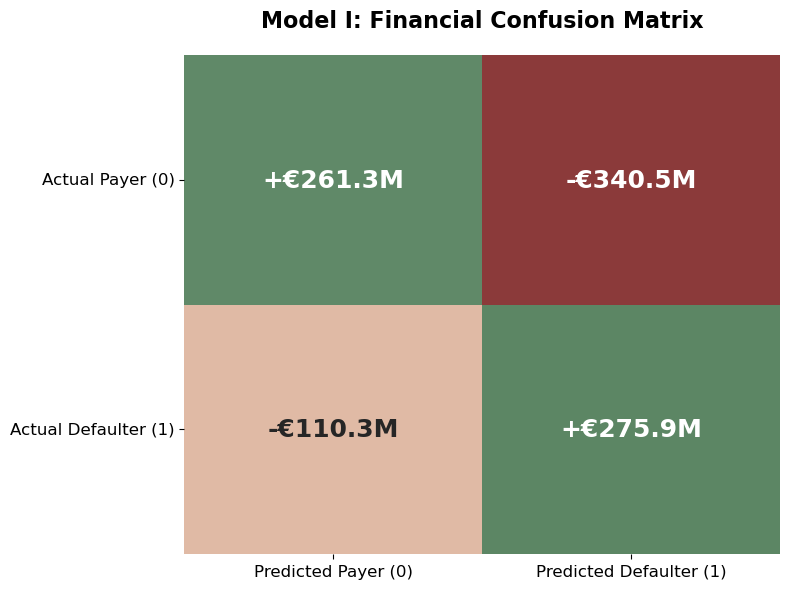

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Matriz financiera del Modelo I (Undersampling) en Millones de Euros
matrix_model1 = np.array([
    [261.3, -340.5],
    [-110.3, 275.9]
])

def format_func(val):
    sign = "+" if val >= 0 else "-"
    return f"{sign}€{abs(val):.1f}M"

# 1. Definir una paleta de colores formales y desaturados
# Orden: [Rojo Ladrillo oscuro, Naranja suave, Gris claro (cero), Verde salvia, Verde bosque]
colores_formales = ["#8B3A3A", "#D49A7A", "#F5F5F5", "#7CA185", "#487550"]
cmap_elegante = LinearSegmentedColormap.from_list("FormalPalette", colores_formales)

plt.figure(figsize=(8, 6))

# 2. Aplicar la nueva paleta (cmap_elegante)
sns.heatmap(matrix_model1, annot=np.vectorize(format_func)(matrix_model1), fmt='', 
            cmap=cmap_elegante, center=0, cbar=False, 
            annot_kws={"size": 18, "weight": "bold"})

# Personalización de títulos y ejes
plt.title('Model I: Financial Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(ticks=[0.5, 1.5], labels=['Predicted Payer (0)', 'Predicted Defaulter (1)'], fontsize=12)
plt.yticks(ticks=[0.5, 1.5], labels=['Actual Payer (0)', 'Actual Defaulter (1)'], rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

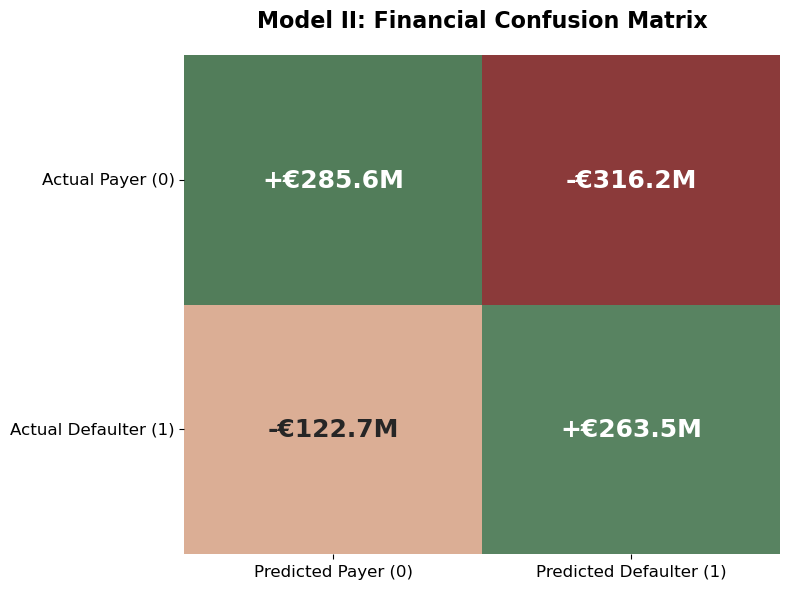

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Matriz financiera del Modelo II (Class Weights)
matrix_model2 = np.array([
    [285.6, -316.2],
    [-122.7, 263.5]
])

def format_func(val):
    sign = "+" if val >= 0 else "-"
    return f"{sign}€{abs(val):.1f}M"

# Paleta formal desaturada
colores_formales = ["#8B3A3A", "#D49A7A", "#F5F5F5", "#7CA185", "#487550"]
cmap_elegante = LinearSegmentedColormap.from_list("FormalPalette", colores_formales)

plt.figure(figsize=(8, 6))

sns.heatmap(matrix_model2, annot=np.vectorize(format_func)(matrix_model2), fmt='', 
            cmap=cmap_elegante, center=0, cbar=False, 
            annot_kws={"size": 18, "weight": "bold"})

plt.title('Model II: Financial Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(ticks=[0.5, 1.5], labels=['Predicted Payer (0)', 'Predicted Defaulter (1)'], fontsize=12)
plt.yticks(ticks=[0.5, 1.5], labels=['Actual Payer (0)', 'Actual Defaulter (1)'], rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

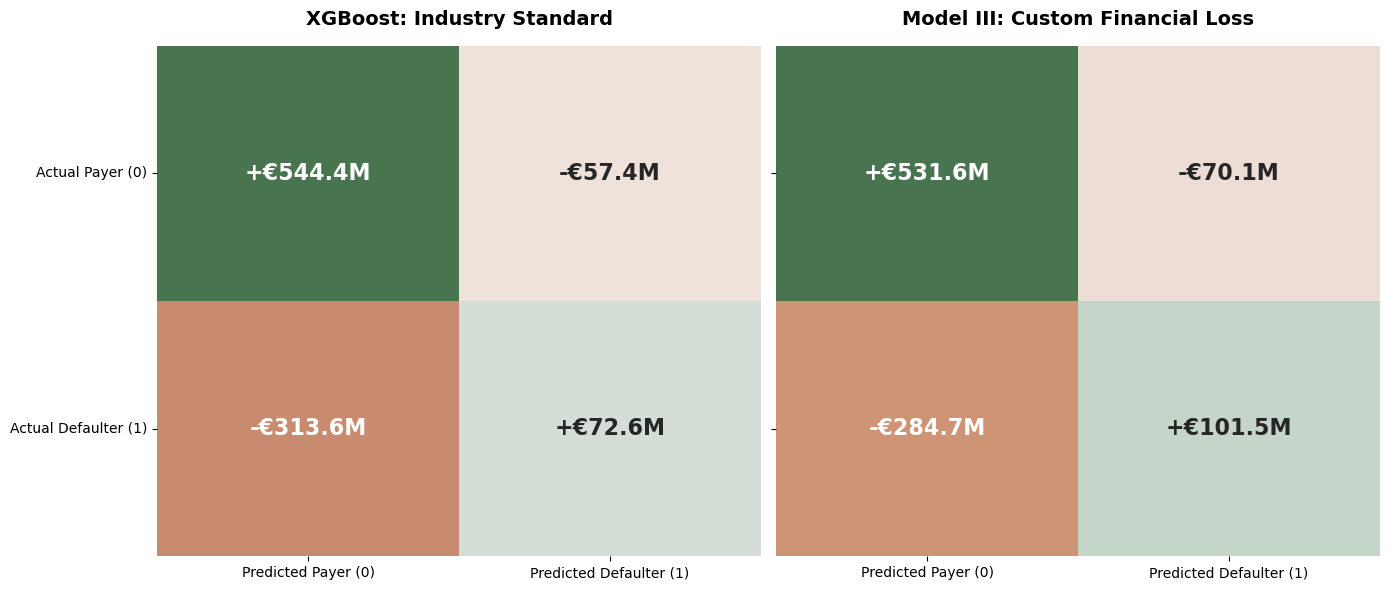

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Datos deducidos de las métricas (en Millones de Euros)
# XGBoost: Net Profit = 230.8M (TN 544.4 - FN 313.6)
matrix_xgb = np.array([
    [544.4, -57.4],
    [-313.6, 72.6]
])

# Model III: Net Profit = 246.9M (TN 531.6 - FN 284.7)
matrix_mod3 = np.array([
    [531.6, -70.1],
    [-284.7, 101.5]
])

def format_func(val):
    sign = "+" if val >= 0 else "-"
    return f"{sign}€{abs(val):.1f}M"

colores_formales = ["#8B3A3A", "#D49A7A", "#F5F5F5", "#7CA185", "#487550"]
cmap_elegante = LinearSegmentedColormap.from_list("FormalPalette", colores_formales)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap XGBoost
sns.heatmap(matrix_xgb, annot=np.vectorize(format_func)(matrix_xgb), fmt='', 
            cmap=cmap_elegante, center=0, cbar=False, ax=axes[0], 
            annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title('XGBoost: Industry Standard', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticks([0.5, 1.5])
axes[0].set_xticklabels(['Predicted Payer (0)', 'Predicted Defaulter (1)'])
axes[0].set_yticks([0.5, 1.5])
axes[0].set_yticklabels(['Actual Payer (0)', 'Actual Defaulter (1)'], rotation=0)

# Heatmap Model III
sns.heatmap(matrix_mod3, annot=np.vectorize(format_func)(matrix_mod3), fmt='', 
            cmap=cmap_elegante, center=0, cbar=False, ax=axes[1], 
            annot_kws={"size": 16, "weight": "bold"})
axes[1].set_title('Model III: Custom Financial Loss', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xticks([0.5, 1.5])
axes[1].set_xticklabels(['Predicted Payer (0)', 'Predicted Defaulter (1)'])
axes[1].set_yticks([0.5, 1.5])
axes[1].set_yticklabels(['', ''], rotation=0)

plt.tight_layout()
plt.show()

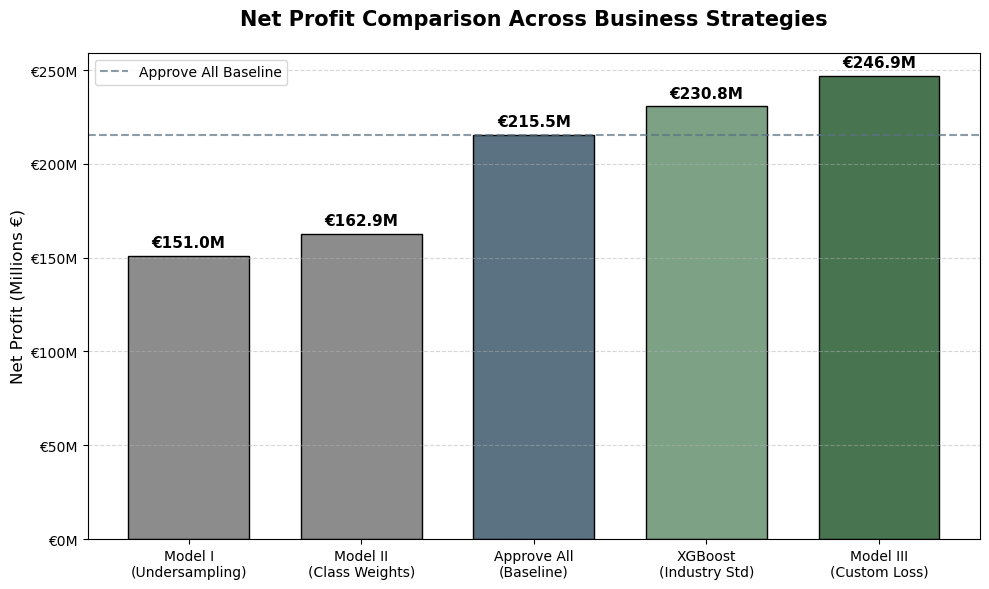

In [15]:
import matplotlib.ticker as ticker

models = ['Model I\n(Undersampling)', 'Model II\n(Class Weights)', 'Approve All\n(Baseline)', 'XGBoost\n(Industry Std)', 'Model III\n(Custom Loss)']
net_profit = [151.0, 162.9, 215.5, 230.8, 246.9]

# Paleta formal: Gris, Gris, Azul Pizarra, Verde Salvia, Verde Bosque
colors = ['#8C8C8C', '#8C8C8C', '#5A7282', '#7CA185', '#487550']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, net_profit, color=colors, edgecolor='black', width=0.7)

# Línea base del Approve All
plt.axhline(y=215.5, color='#5A7282', linestyle='--', alpha=0.7, label='Approve All Baseline')

# Etiquetas de datos
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 3, f'€{yval:.1f}M', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'€{x:.0f}M'))
plt.title('Net Profit Comparison Across Business Strategies', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Net Profit (Millions €)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

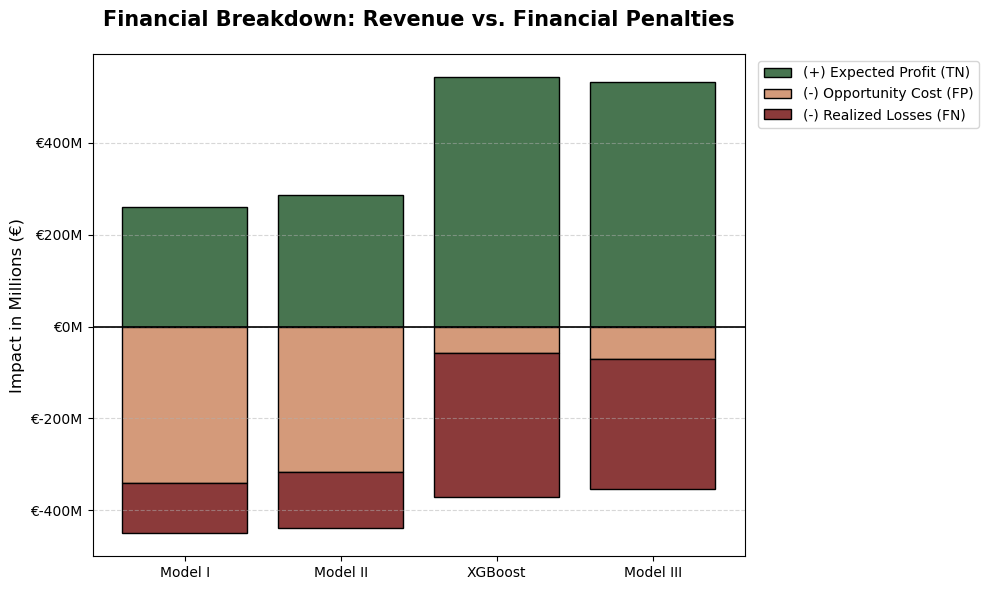

In [16]:
models_stack = ['Model I', 'Model II', 'XGBoost', 'Model III']
# Datos positivos (Expected Profit / TN)
revenue = np.array([261.3, 285.6, 544.4, 531.6])
# Datos negativos
opp_cost = np.array([-340.5, -316.2, -57.4, -70.1]) # Falsos Positivos
realized_losses = np.array([-110.3, -122.7, -313.6, -284.7]) # Falsos Negativos

plt.figure(figsize=(10, 6))

# Barras positivas (Verde Bosque)
plt.bar(models_stack, revenue, color='#487550', edgecolor='black', label='(+) Expected Profit (TN)')

# Barras negativas apiladas (Naranja Arcilla y Rojo Ladrillo)
plt.bar(models_stack, opp_cost, color='#D49A7A', edgecolor='black', label='(-) Opportunity Cost (FP)')
plt.bar(models_stack, realized_losses, bottom=opp_cost, color='#8B3A3A', edgecolor='black', label='(-) Realized Losses (FN)')

plt.axhline(0, color='black', linewidth=1.2)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'€{x:.0f}M'))

plt.title('Financial Breakdown: Revenue vs. Financial Penalties', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Impact in Millions (€)', fontsize=12)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

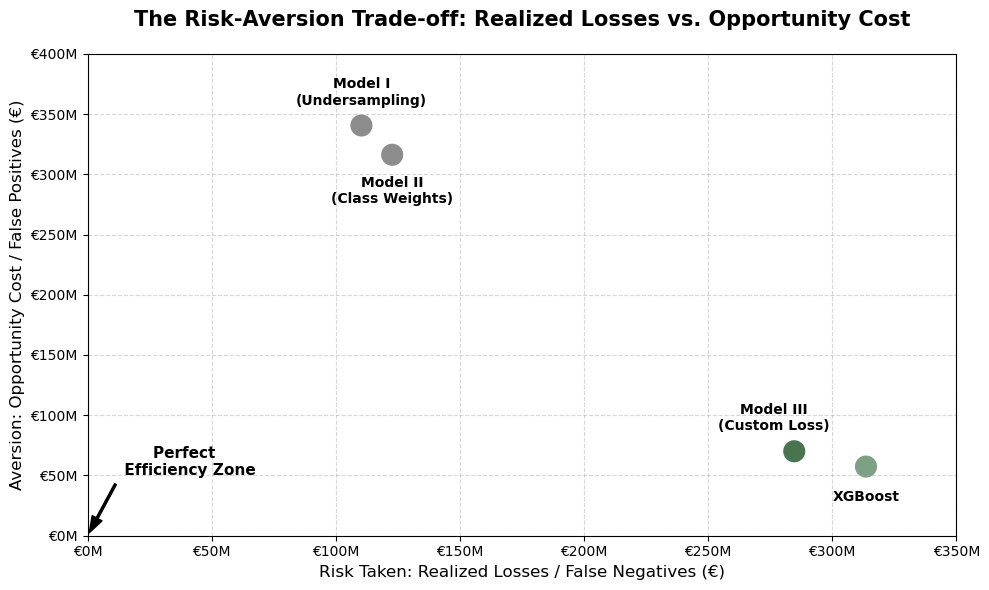

In [19]:
models_scatter = ['Model I\n(Undersampling)', 'Model II\n(Class Weights)', 'XGBoost', 'Model III\n(Custom Loss)']
fn_x = [110.3, 122.7, 313.6, 284.7]
fp_y = [340.5, 316.2, 57.4, 70.1]

# Gris, Gris, Verde Salvia, Verde Bosque
colors_scatter = ['#8C8C8C', '#8C8C8C', '#7CA185', '#487550']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fn_x, y=fp_y, s=300, hue=models_scatter, palette=colors_scatter, legend=False)

# Ajuste manual de posiciones para evitar superposiciones
offsets = [
    (0, 15),   # Model I (arriba)
    (0, -35),  # Model II (abajo)
    (0, -25),  # XGBoost (abajo)
    (-15, 15)  # Model III (arriba a la izquierda)
]

for i, txt in enumerate(models_scatter):
    plt.annotate(txt, (fn_x[i], fp_y[i]), xytext=offsets[i], 
                 textcoords='offset points', ha='center', fontsize=10, fontweight='bold')

plt.annotate('Perfect \n Efficiency Zone', xy=(0, 0), xytext=(40, 50),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, fontweight='bold', ha='center')

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'€{x:.0f}M'))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'€{x:.0f}M'))

plt.xlim(0, 350)
plt.ylim(0, 400)
plt.title('The Risk-Aversion Trade-off: Realized Losses vs. Opportunity Cost', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Risk Taken: Realized Losses / False Negatives (€)', fontsize=12)
plt.ylabel('Aversion: Opportunity Cost / False Positives (€)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

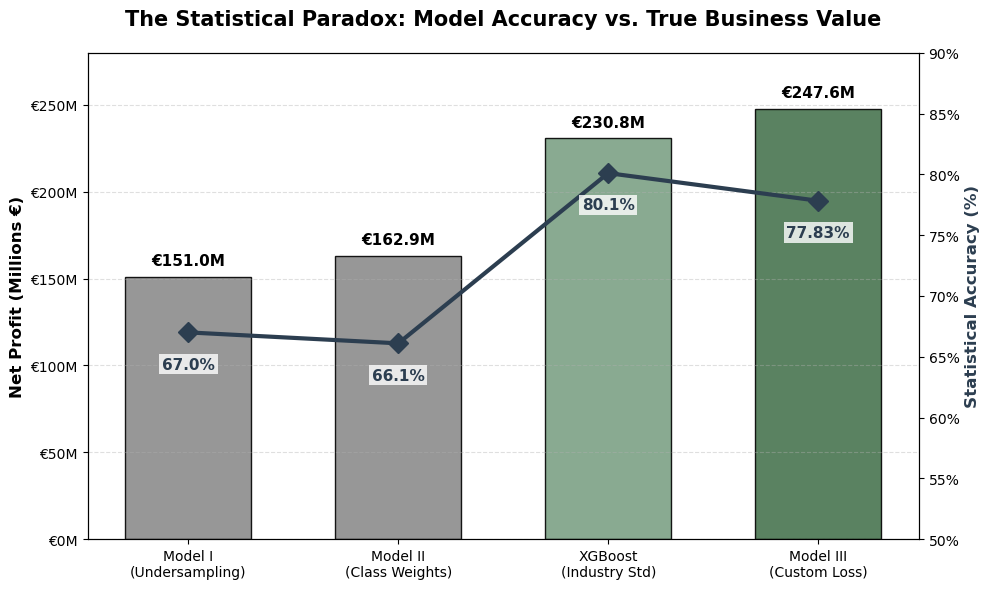

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

models = ['Model I\n(Undersampling)', 'Model II\n(Class Weights)', 'XGBoost\n(Industry Std)', 'Model III\n(Custom Loss)']
net_profit = [151.0, 162.9, 230.8, 247.6]
accuracy = [67.0, 66.1, 80.76, 77.83] 

# Paleta formal: Gris, Gris, Verde Salvia, Verde Bosque
colors_bars = ['#8C8C8C', '#8C8C8C', '#7CA185', '#487550']

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje 1 (Izquierdo): Beneficio Neto en Barras
bars = ax1.bar(models, net_profit, color=colors_bars, edgecolor='black', width=0.6, alpha=0.9)
ax1.set_ylabel('Net Profit (Millions €)', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'€{x:.0f}M'))
ax1.set_ylim(0, 280)

# Eje 2 (Derecho): Accuracy en Línea
ax2 = ax1.twinx()
line = ax2.plot(models, accuracy, color='#2C3E50', marker='D', markersize=10, linewidth=3, linestyle='-', label='Accuracy (%)')
ax2.set_ylabel('Statistical Accuracy (%)', fontsize=12, fontweight='bold', color='#2C3E50')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.0f}%'))
ax2.set_ylim(50, 90)

# Añadir etiquetas a las barras (Dinero por encima)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 5, f'€{yval:.1f}M', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Añadir etiquetas a la línea de Accuracy (Por DEBAJO del punto y con fondo blanco)
for i, acc in enumerate(accuracy):
    ax2.text(i, acc - 2, f'{acc}%', ha='center', va='top', fontweight='bold', color='#2C3E50', fontsize=11,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

plt.title('The Statistical Paradox: Model Accuracy vs. True Business Value', fontsize=15, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

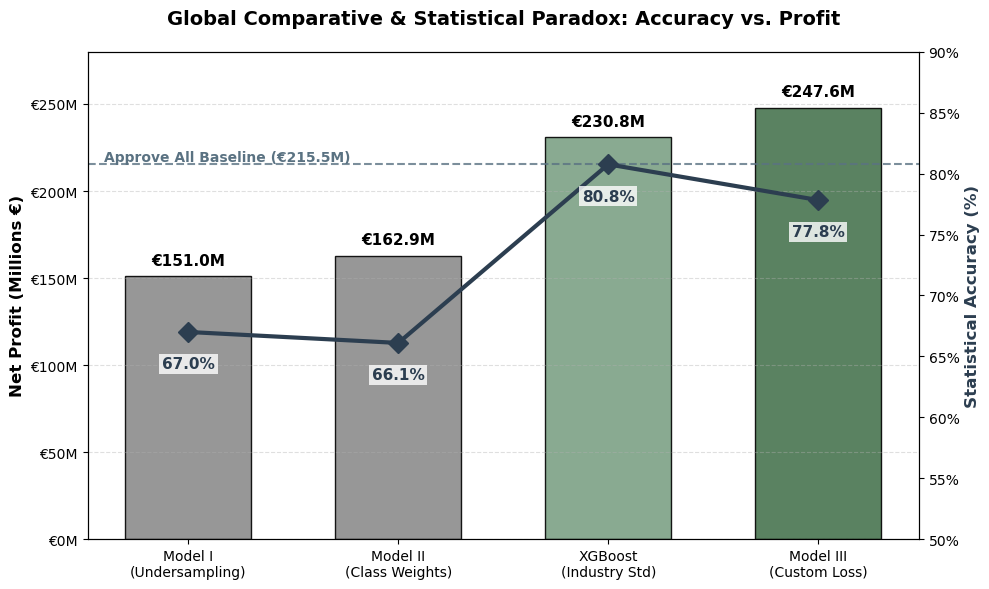

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

models = ['Model I\n(Undersampling)', 'Model II\n(Class Weights)', 'XGBoost\n(Industry Std)', 'Model III\n(Custom Loss)']
net_profit = [151.0, 162.9, 230.8, 247.6] # Actualizado al profit real del Mod III
accuracy = [67.0, 66.1, 80.76, 77.83] # Actualizado a las accuracy reales

# Paleta formal
colors_bars = ['#8C8C8C', '#8C8C8C', '#7CA185', '#487550']

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje 1 (Izquierdo): Beneficio Neto en Barras
bars = ax1.bar(models, net_profit, color=colors_bars, edgecolor='black', width=0.6, alpha=0.9)
ax1.set_ylabel('Net Profit (Millions €)', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'€{x:.0f}M'))
ax1.set_ylim(0, 280)

# LÍNEA BASE AÑADIDA: Approve All
ax1.axhline(y=215.5, color='#5A7282', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.text(-0.4, 217, 'Approve All Baseline (€215.5M)', color='#5A7282', fontsize=10, fontweight='bold')

# Eje 2 (Derecho): Accuracy en Línea
ax2 = ax1.twinx()
line = ax2.plot(models, accuracy, color='#2C3E50', marker='D', markersize=10, linewidth=3, linestyle='-', label='Accuracy (%)')
ax2.set_ylabel('Statistical Accuracy (%)', fontsize=12, fontweight='bold', color='#2C3E50')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.0f}%'))
ax2.set_ylim(50, 90)

# Añadir etiquetas a las barras
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 5, f'€{yval:.1f}M', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Añadir etiquetas a la línea de Accuracy (Por debajo y con fondo)
for i, acc in enumerate(accuracy):
    ax2.text(i, acc - 2, f'{acc:.1f}%', ha='center', va='top', fontweight='bold', color='#2C3E50', fontsize=11,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

plt.title('Global Comparative & Statistical Paradox: Accuracy vs. Profit', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

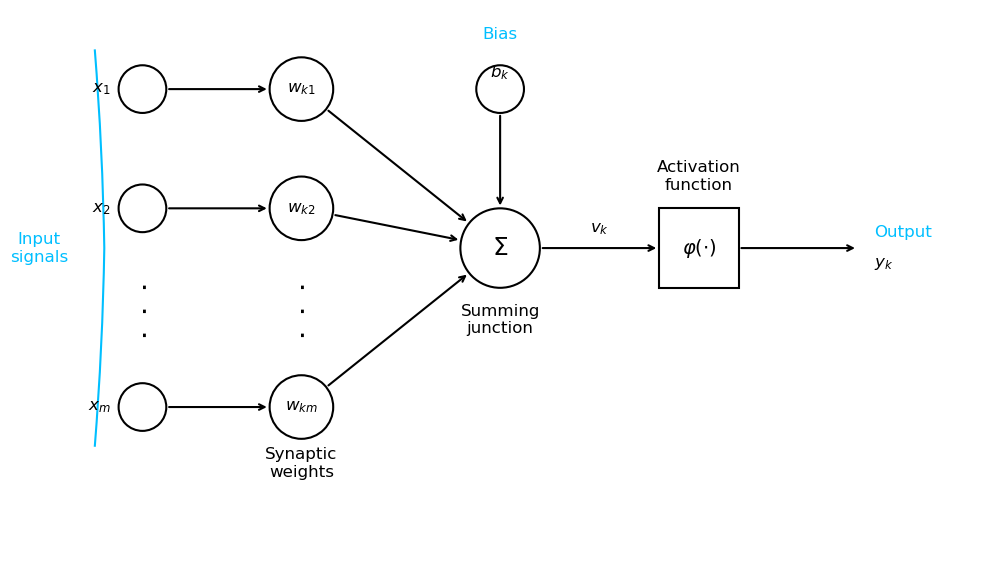

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Configuración de la figura y el área de dibujo
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 6)
ax.axis('off')  # Ocultar los ejes para un lienzo limpio

# --- Definición de elementos y posiciones ---

# Color azul específico para etiquetas principales
cyan_color = '#00BFFF'  # Deep Sky Blue

# Entradas y Pesos (y_posiciones, etiquetas x_i, etiquetas w_ki)
entries = [
    (5.0, r'$x_1$', r'$w_{k1}$'),
    (3.5, r'$x_2$', r'$w_{k2}$'),
    (1.0, r'$x_m$', r'$w_{km}$')
]

# Nodos de entrada y peso
node_radius = 0.3
weight_node_radius = 0.4

# Dibujar las entradas y pesos con puntos suspensivos
x_in = 0.5
x_weight = 2.5

for y_in, label_in, label_w in entries:
    # Nodos de entrada
    ax.add_patch(patches.Circle((x_in, y_in), node_radius, fill=False, edgecolor='black', linewidth=1.5))
    ax.text(x_in - 0.4, y_in, label_in, fontsize=12, va='center', ha='right')

    # Nodos de peso
    ax.add_patch(patches.Circle((x_weight, y_in), weight_node_radius, fill=False, edgecolor='black', linewidth=1.5))
    ax.text(x_weight, y_in, label_w, fontsize=12, va='center', ha='center', weight='bold')

    # Flechas de entrada a peso
    ax.annotate("", xy=(x_weight - weight_node_radius, y_in), xytext=(x_in + node_radius, y_in),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color="black", linewidth=1.5))

# Puntos suspensivos para entradas y pesos
ax.text(x_in, 2.5, '$\cdot$', fontsize=20, va='center', ha='center')
ax.text(x_in, 2.2, '$\cdot$', fontsize=20, va='center', ha='center')
ax.text(x_in, 1.9, '$\cdot$', fontsize=20, va='center', ha='center')

ax.text(x_weight, 2.5, '$\cdot$', fontsize=20, va='center', ha='center')
ax.text(x_weight, 2.2, '$\cdot$', fontsize=20, va='center', ha='center')
ax.text(x_weight, 1.9, '$\cdot$', fontsize=20, va='center', ha='center')

# --- Unión Sumadora y Flechas ---
x_sum = 5.0
y_sum = 3.0
sum_node_radius = 0.5

# Nodo de unión sumadora
ax.add_patch(patches.Circle((x_sum, y_sum), sum_node_radius, fill=False, edgecolor='black', linewidth=1.5))
ax.text(x_sum, y_sum, r'$\Sigma$', fontsize=18, va='center', ha='center', weight='bold')

# Flechas de pesos a unión sumadora
for _, _, label_w in entries:
    # Determinar la posición de origen del peso
    y_src = next(item[0] for item in entries if item[2] == label_w)
    ax.annotate("", xy=(x_sum - sum_node_radius * np.cos(np.arctan2(y_src - y_sum, x_weight - x_sum) + np.pi), 
                        y_sum - sum_node_radius * np.sin(np.arctan2(y_src - y_sum, x_weight - x_sum) + np.pi)), 
                xytext=(x_weight + weight_node_radius * np.cos(np.arctan2(y_sum - y_src, x_sum - x_weight)), 
                        y_src + weight_node_radius * np.sin(np.arctan2(y_sum - y_src, x_sum - x_weight))),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color="black", linewidth=1.5))

# --- Sesgo (Bias) ---
x_bias = 5.0
y_bias = 5.0
bias_node_radius = node_radius

# Nodo del sesgo
ax.add_patch(patches.Circle((x_bias, y_bias), bias_node_radius, fill=False, edgecolor='black', linewidth=1.5))
# Etiquetas del sesgo (Texto y variable)
ax.text(x_bias, y_bias + 0.6, 'Bias', fontsize=12, color=cyan_color, va='bottom', ha='center')
ax.text(x_bias, y_bias + 0.1, r'$b_k$', fontsize=12, va='bottom', ha='center')

# Flecha del sesgo a unión sumadora
ax.annotate("", xy=(x_sum, y_sum + sum_node_radius), xytext=(x_bias, y_bias - bias_node_radius),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color="black", linewidth=1.5))

# --- Función de Activación ---
x_act = 7.5
y_act = y_sum
act_width = 1.0
act_height = 1.0

# Rectángulo de la función de activación
ax.add_patch(patches.Rectangle((x_act - act_width / 2, y_act - act_height / 2), act_width, act_height, 
                              fill=False, edgecolor='black', linewidth=1.5))
ax.text(x_act, y_act, r'$\varphi(\cdot)$', fontsize=14, va='center', ha='center', weight='bold')

# Etiqueta sobre la función de activación
ax.text(x_act, y_act + 0.7, 'Activation\nfunction', fontsize=12, va='bottom', ha='center')

# Flecha de la unión sumadora a la función de activación (con $v_k$)
ax.annotate("", xy=(x_act - act_width / 2, y_act), xytext=(x_sum + sum_node_radius, y_sum),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color="black", linewidth=1.5))
ax.text((x_act - act_width / 2 + x_sum + sum_node_radius) / 2, y_act + 0.15, r'$v_k$', fontsize=12, va='bottom', ha='center')

# --- Salida ---
x_out = 9.5
y_out = y_act

# Flecha de salida
ax.annotate("", xy=(x_out, y_out), xytext=(x_act + act_width / 2, y_act),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color="black", linewidth=1.5))

# Etiquetas de salida (Texto y variable)
ax.text(x_out + 0.2, y_out + 0.1, 'Output', fontsize=12, color=cyan_color, va='bottom', ha='left')
ax.text(x_out + 0.2, y_out - 0.1, r'$y_k$', fontsize=12, va='top', ha='left')

# --- Etiquetas de Texto Principales ---

# Input signals (con llave)
ax.text(-0.8, 3.0, 'Input\nsignals', fontsize=12, color=cyan_color, va='center', ha='center', fontweight='normal')

# Llave vertical para 'Input signals'
# Esto se puede hacer con una Path para ser exactos, o una aproximación con texto grande.
# Una simple aproximación con una línea curva funciona bien.
y_start = 5.5
y_end = 0.5
brace_x = -0.1
brace_width = 0.1
# Crear una llave con múltiples puntos para la curva
brace_path = patches.PathPatch(
    patches.Path([
        (brace_x, y_start), 
        (brace_x + brace_width, (y_start + 3.0)/2), 
        (brace_x + brace_width * 1.2, 3.0),
        (brace_x + brace_width, (y_end + 3.0)/2),
        (brace_x, y_end)
    ], [
        patches.Path.MOVETO, 
        patches.Path.CURVE3, 
        patches.Path.CURVE3, 
        patches.Path.CURVE3, 
        patches.Path.CURVE3
    ]), 
    fill=False, edgecolor=cyan_color, linewidth=1.5
)
ax.add_patch(brace_path)

# Synaptic weights
ax.text(x_weight, 0.5, 'Synaptic\nweights', fontsize=12, va='top', ha='center', linespacing=1.2)

# Summing junction
ax.text(x_sum, 2.3, 'Summing\njunction', fontsize=12, va='top', ha='center')

# Ajustar la relación de aspecto para que se vea bien
ax.set_aspect('equal')

# Mostrar el diagrama
plt.tight_layout()
plt.show()